# 10e — Weitzman's "prices vs. quantities"

Covers `chap10_externality5a.m`, `5b.m`, `5d.m`, `5e.m`: Weitzman's
(1974) classic result on choosing a **quantity instrument** (an
emissions cap, fixed regardless of how costly abatement turns out to
be) versus a **price instrument** (an emissions tax, fixed regardless
of the resulting quantity) when the regulator sets policy *before*
observing the true realization of marginal abatement cost.

`chap10_externality5c.m` is a near-duplicate of `5b.m` — identical
$\alpha_B,\beta_B,\alpha_C,\beta_C,\epsilon_i,p_i$ inputs, just a
condensed re-run that drops the intermediate numerical-integration
check — so it is noted here and not rebuilt separately, per this
project's standing convention for near-duplicate scripts.

**The model.** Social marginal benefit is linear and known:
$SMB(q)=\alpha_B-\beta_B q$. Social marginal cost is linear but
uncertain: $SMC(q,\epsilon)=\alpha_C+\beta_C q+\epsilon$, where
$\epsilon$ is a random shock (a discrete distribution $\{\epsilon_i,
p_i\}$ here) not yet known when the instrument is chosen. The regulator
sets policy using only the *expected* cost curve (i.e. $\mathrm{E}
[\epsilon]$), then the shock $\epsilon_i$ is realized:

- **Quantity instrument**: cap quantity at $q_1^{\star}$, the quantity
  that would be optimal under the *expected* cost curve. This quantity
  never adjusts to the realized shock.
- **Price instrument**: set a tax equal to $p^{\star}$, the price that
  would clear the market under the *expected* cost curve. Firms then
  choose $q_2^{\star}(\epsilon_i)$ so that $SMC(q,\epsilon_i)=p^{\star}$
  — this quantity *does* adjust to the realized shock, since the firm
  observes its own true marginal cost even though the regulator didn't.

Realized welfare is $W(q,\epsilon)=\int_0^q\left[SMB(x)-SMC(x,\epsilon)
\right]dx$. Weitzman's result: $\mathrm{E}[W(q_2^{\star})]-\mathrm{E}
[W(q_1^{\star})] = \dfrac{\sigma_\epsilon^2}{2\beta_C}\left(1-\dfrac
{\beta_B}{\beta_C}\right)$ — the price instrument wins exactly when the
marginal-cost curve is steeper than the marginal-benefit curve
($\beta_C>\beta_B$), and the quantity instrument wins when it's the
other way around. All sections are self-contained (hardcoded
illustrative parameters, no external data).

In [1]:
import numpy as np
import pandas as pd
from scipy.integrate import quad

def weitzman_example(alpha_B, beta_B, alpha_C, beta_C, epsilon_i, p_i, check_numerical=False):
    epsilon_i = np.asarray(epsilon_i, dtype=float)
    p_i = np.asarray(p_i, dtype=float)
    mean_epsilon = np.sum(p_i * epsilon_i)
    sigma_epsilon = np.sqrt(np.sum(p_i * (epsilon_i - mean_epsilon) ** 2))

    # True (ex-post) optimal quantity under each realized shock
    q_star_i = (alpha_B - alpha_C - epsilon_i) / (beta_B + beta_C)

    # Ex-ante optimum under the *expected* cost curve
    q_ast = (alpha_B - alpha_C - mean_epsilon) / (beta_B + beta_C)
    p_ast = alpha_B - beta_B * q_ast

    # Quantity instrument: cap fixed at q_ast for every state
    q1_ast_i = np.full_like(epsilon_i, q_ast)

    # Price instrument: firms equate SMC(q, epsilon_i) to the fixed price p_ast
    q2_ast_i = (p_ast - alpha_C - epsilon_i) / beta_C

    def dW(q, epsilon):
        return (alpha_B - beta_B * q) - (alpha_C + beta_C * q + epsilon)

    def W_analytical(q, epsilon):
        return ((alpha_B - alpha_C - epsilon) - 0.5 * q * (beta_B + beta_C)) * q

    if check_numerical:
        W_numerical = np.array([[quad(dW, 0, qv, args=(eps,))[0] for qv in [0, 1, 2, 3, 4]]
                                 for eps in epsilon_i])
        W_check = np.array([[W_analytical(qv, eps) for qv in [0, 1, 2, 3, 4]]
                             for eps in epsilon_i])
        max_err = np.max(np.abs(W_numerical - W_check))
        print(f"Max |analytical - numerical (scipy.integrate.quad)| welfare error: {max_err:.2e}")

    W_q1_ast_i = W_analytical(q1_ast_i, epsilon_i)
    W_q2_ast_i = W_analytical(q2_ast_i, epsilon_i)
    E_W_q1_ast = np.sum(p_i * W_q1_ast_i)
    E_W_q2_ast = np.sum(p_i * W_q2_ast_i)
    Delta_W = E_W_q2_ast - E_W_q1_ast
    Delta_W_analytical = sigma_epsilon ** 2 * (1 - beta_B / beta_C) / (2 * beta_C)

    table = pd.DataFrame({
        "epsilon_i": epsilon_i, "p_i": p_i,
        "q*_i (ex-post optimum)": q_star_i,
        "q1*_i (quantity instr.)": q1_ast_i,
        "q2*_i (price instr.)": q2_ast_i,
        "W(q1*_i)": W_q1_ast_i, "W(q2*_i)": W_q2_ast_i,
    })
    display(table.round(3))
    print(f"mean(epsilon) = {mean_epsilon:.3f}, sigma(epsilon) = {sigma_epsilon:.3f}")
    print(f"q* = {q_ast:.3f}, p* = {p_ast:.3f}")
    print(f"E[W(q1*)] (quantity instrument) = {E_W_q1_ast:.4f}")
    print(f"E[W(q2*)] (price instrument)    = {E_W_q2_ast:.4f}")
    print(f"Delta(W) = E[W(q2*)] - E[W(q1*)] = {Delta_W:.4f}  "
          f"(closed form: {Delta_W_analytical:.4f})")
    winner = "price" if Delta_W > 0 else "quantity"
    print(f"-> beta_C={beta_C} {'>' if beta_C > beta_B else '<'} beta_B={beta_B}, "
          f"so the {winner} instrument dominates in expectation.")
    return dict(q_ast=q_ast, p_ast=p_ast, mean_epsilon=mean_epsilon, sigma_epsilon=sigma_epsilon,
                E_W_q1_ast=E_W_q1_ast, E_W_q2_ast=E_W_q2_ast, Delta_W=Delta_W)

## 1. Two-state uncertainty (`chap10_externality5a.m`)

A simple symmetric two-state cost shock: $\epsilon\in\{+30,-30\}$ with
equal probability. $\beta_C=8 > \beta_B=2$ (the marginal-cost curve is
much steeper than the marginal-benefit curve), so Weitzman's result
predicts the price instrument should dominate. The welfare integral is
also cross-checked analytically against `scipy.integrate.quad`
(mirroring the source script's own numerical-vs-analytical check via
MATLAB's `integral`).

In [2]:
_ = weitzman_example(alpha_B=100, beta_B=2, alpha_C=20, beta_C=8,
                      epsilon_i=[30, -30], p_i=[0.50, 0.50], check_numerical=True)

Max |analytical - numerical (scipy.integrate.quad)| welfare error: 1.42e-14


,epsilon_i,p_i,q*_i (ex-post optimum),q1*_i (quantity instr.),q2*_i (price instr.),W(q1*_i),W(q2*_i)
0,30.0,0.5,5.0,8.0,4.25,80.0,122.188
1,-30.0,0.5,11.0,8.0,11.75,560.0,602.188


mean(epsilon) = 0.000, sigma(epsilon) = 30.000
q* = 8.000, p* = 84.000
E[W(q1*)] (quantity instrument) = 320.0000
E[W(q2*)] (price instrument)    = 362.1875
Delta(W) = E[W(q2*)] - E[W(q1*)] = 42.1875  (closed form: 42.1875)
-> beta_C=8 > beta_B=2, so the price instrument dominates in expectation.


## 2. Three-state uncertainty (`chap10_externality5b.m`)

A right-skewed three-state cost shock. Same qualitative conclusion
($\beta_C=8 > \beta_B=2$): the price instrument wins in expectation,
though by a different margin since the shock distribution has changed.
(`chap10_externality5c.m` reruns this exact case without the numerical
check — skipped here as a near-duplicate.)

In [3]:
_ = weitzman_example(alpha_B=100, beta_B=2, alpha_C=20, beta_C=8,
                      epsilon_i=[10, 30, 50], p_i=[0.40, 0.35, 0.25])

,epsilon_i,p_i,q*_i (ex-post optimum),q1*_i (quantity instr.),q2*_i (price instr.),W(q1*_i),W(q2*_i)
0,10.0,0.40,7.0,5.3,7.425,230.55,244.097
1,30.0,0.35,5.0,5.3,4.925,124.55,124.972
2,50.0,0.25,3.0,5.3,2.425,18.55,43.347


mean(epsilon) = 27.000, sigma(epsilon) = 15.843
q* = 5.300, p* = 89.400
E[W(q1*)] (quantity instrument) = 140.4500
E[W(q2*)] (price instrument)    = 152.2156
Delta(W) = E[W(q2*)] - E[W(q1*)] = 11.7656  (closed form: 11.7656)
-> beta_C=8 > beta_B=2, so the price instrument dominates in expectation.


## 3. Closer slopes — a smaller margin (`chap10_externality5d.m`)

Now the two curves' slopes are much closer ($\beta_C=5$ vs.
$\beta_B=4$), so the price instrument's advantage should shrink
relative to Sections 1-2. This case is also the $\beta_C=5$ point of
the slope sweep built in Section 4.

In [4]:
_ = weitzman_example(alpha_B=100, beta_B=4, alpha_C=20, beta_C=5,
                      epsilon_i=[10, 25, 50], p_i=[0.40, 0.50, 0.10])

,epsilon_i,p_i,q*_i (ex-post optimum),q1*_i (quantity instr.),q2*_i (price instr.),W(q1*_i),W(q2*_i)
0,10.0,0.4,7.778,6.5,8.8,264.875,267.52
1,25.0,0.5,6.111,6.5,5.8,167.375,167.62
2,50.0,0.1,3.333,6.5,0.8,4.875,21.12


mean(epsilon) = 21.500, sigma(epsilon) = 11.843
q* = 6.500, p* = 74.000
E[W(q1*)] (quantity instrument) = 190.1250
E[W(q2*)] (price instrument)    = 192.9300
Delta(W) = E[W(q2*)] - E[W(q1*)] = 2.8050  (closed form: 2.8050)
-> beta_C=5 > beta_B=4, so the price instrument dominates in expectation.


## 4. Sweeping the cost-curve slope (`chap10_externality5e.m`)

Repeats Section 3's setup for a range of $\beta_C$ values from 1 to 10
(holding $\beta_B=4$ fixed), plotting $\mathrm{E}[W(q_1^{\star})]$ and
$\mathrm{E}[W(q_2^{\star})]$ against $\beta_C$. The two curves cross
exactly at $\beta_C=\beta_B=4$ (dotted vertical line): for
$\beta_C<\beta_B$ the quantity instrument dominates (shaded red,
$\Delta\le 0$); for $\beta_C>\beta_B$ the price instrument dominates
(shaded teal, $\Delta\ge 0$) — this is Weitzman's rule visualized
directly.

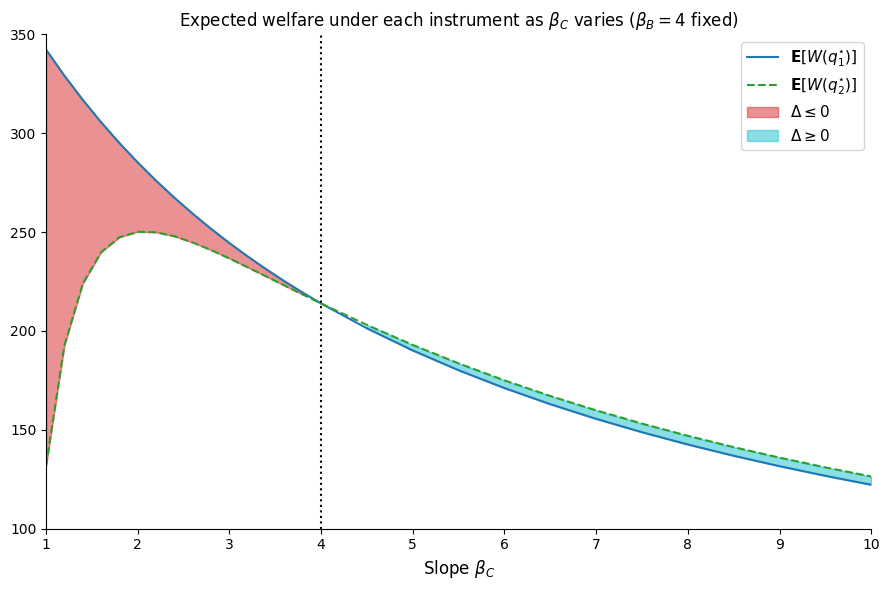

In [5]:
import matplotlib.pyplot as plt

color_blue = "#1f77b4"
color_green = "#2ca02c"
color_red = "#d62728"
color_teal = "#17becf"
color_black = "#000000"

alpha_B, beta_B, alpha_C = 100, 4, 20
epsilon_i = np.array([10, 25, 50], dtype=float)
p_i = np.array([0.40, 0.50, 0.10])
mean_epsilon = np.sum(p_i * epsilon_i)
sigma_epsilon = np.sqrt(np.sum(p_i * (epsilon_i - mean_epsilon) ** 2))

beta_C_vector = np.concatenate([np.arange(1, 4, 0.2), np.arange(4, 10.5, 0.5)])
E_W_q1 = np.zeros_like(beta_C_vector)
E_W_q2 = np.zeros_like(beta_C_vector)
Delta_W = np.zeros_like(beta_C_vector)

for i, beta_C in enumerate(beta_C_vector):
    E_W_q1[i] = 0.5 * (alpha_B - alpha_C - mean_epsilon) ** 2 / (beta_B + beta_C)
    E_W_q2[i] = ((alpha_B - alpha_C - mean_epsilon) ** 2 * beta_C ** 2
                 + sigma_epsilon ** 2 * (beta_C ** 2 - beta_B ** 2)) / (2 * (beta_B + beta_C) * beta_C ** 2)
    Delta_W[i] = sigma_epsilon ** 2 * (1 - beta_B / beta_C) / (2 * beta_C)

fig, ax = plt.subplots(figsize=(9, 6))
line1, = ax.plot(beta_C_vector, E_W_q1, "-", color=color_blue, lw=1.5)
line2, = ax.plot(beta_C_vector, E_W_q2, "--", color=color_green, lw=1.5)
ax.plot([beta_B, beta_B], [100, 350], ":", color=color_black, lw=1.5)

cnd = Delta_W < 0
patch1 = ax.fill_between(beta_C_vector[cnd], E_W_q1[cnd], E_W_q2[cnd], color=color_red, alpha=0.50)
cnd = Delta_W > 0
patch2 = ax.fill_between(beta_C_vector[cnd], E_W_q1[cnd], E_W_q2[cnd], color=color_teal, alpha=0.50)

ax.set_xlim(1, 10)
ax.set_ylim(100, 350)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xlabel(r"Slope $\beta_C$", fontsize=12)
ax.legend([line1, line2, patch1, patch2],
          [r"$\mathbf{E}[W(q_1^{\star})]$", r"$\mathbf{E}[W(q_2^{\star})]$",
           r"$\Delta \leq 0$", r"$\Delta \geq 0$"], fontsize=11, loc="upper right")
ax.set_title(r"Expected welfare under each instrument as $\beta_C$ varies ($\beta_B=4$ fixed)")
plt.tight_layout()
plt.show()